In [4]:
import numpy as np
import matplotlib.pyplot as plt
import athena_mc as athenamc

In [5]:
folder = "xrb_d01_s3_1e9"

In [6]:
spec = athenamc.read_spectrum(f"../{folder}/xrb.out1.spec")
print(spec.keys())

dict_keys(['dt', 'nx', 'nmu', 'nphi', 'ntot', 'nintens', 'units', 'polarized', 'yerror', 'xfaces', 'mufaces', 'phifaces', 'intensity', 'errors'])


In [7]:
imu = 0
iphi = 0

xfaces = spec['xfaces']
x = 0.5*(xfaces[1:]+xfaces[:-1])
y = spec["intensity"][0,iphi,imu,:]
yerr = spec["errors"][0,iphi,imu,:]

print(x.shape, y.shape, yerr.shape)

np.savetxt(
    "output.txt",
    np.column_stack([x, y, yerr]),
    header="x y yerr"
)

(48,) (48,) (48,)


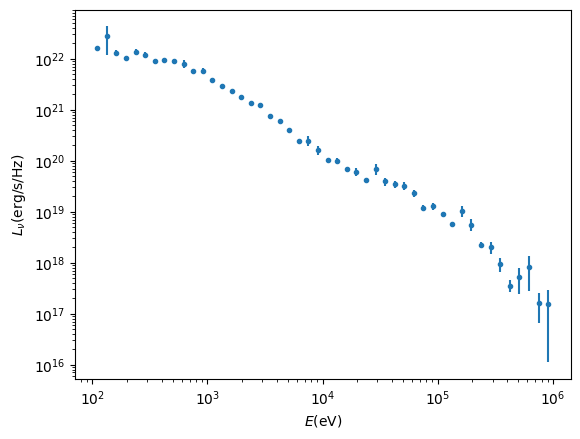

In [9]:
x, y, yerr = np.loadtxt("output.txt", unpack=True)

# Plot
plt.errorbar(x, y, yerr=yerr, fmt='o', markersize=3)

# Labels
plt.xlabel(r"$E {\rm (eV)}$")
plt.ylabel(r"$L_\nu {\rm (erg/s/Hz)}$")

# Optional: log scales (very common for spectra)
plt.xscale("log")
plt.yscale("log")

plt.show()